🟦 1. Introduction

This stage focuses on preparing the dataset for machine learning and identifying undervalued micro-markets using clustering techniques. The goal is to group similar properties and detect clusters with lower price per square foot.

🟦 2. Load Processed Data

The cleaned dataset is loaded for final preprocessing and modeling.

In [8]:
import pandas as pd
df = pd.read_csv("../data/processed/cleaned_data.csv")

df.head()

,listing_id,internal_id,category,listing_type,detail_url,property_type,offering_type,completion_status,title,price_egp,...,agent_is_super,agent_languages,broker_id,broker_name,broker_email,broker_phone,contact_phone,contact_whatsapp,contact_email,scraped_at
0,F7QB31CGWE509V2W7DF2GARB2C,56009081.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/duple...,Duplex,Residential for Sale,completed,Garden Villa - Lake View Boutique - Prime Loca...,24500000.0,...,False,NaN,5758.0,Spade consultancy,mohmedg.sedik@gmail.com,1.001437e+09,2.012018e+11,2.022126e+10,pierre.Osama@spade-consultancy.com,2026-03-04T14:20:33.281007
1,K1JC3D6N57ED52N3VX1QQKHHXG,56247925.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,off_plan,For Sale: Finished Apartment+ ACs in Village West,5145000.0,...,False,NaN,492.0,Abrag Real Estate,snawara71@gmail.com,2.010012e+11,2.010072e+11,2.022126e+10,ranoushamer901@gmail.com,2026-03-04T14:20:33.281007
2,Q6GEB8T6PZTJGNNPWA5PX3JCWR,56253883.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,UnderMarket Price for Apt. 250 RTM PrimeLocation,10800000.0,...,False,English | Arabic,5279.0,Premises,mahmouddessam@hotmail.com,2.010051e+11,2.010910e+11,2.022126e+10,ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007
3,PPH0852SAB266X6GSVATJP4F0M,56250852.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,lowest price 2bds fullyfurnished @ lake view,10500000.0,...,False,English | Arabic,5758.0,Spade consultancy,mohmedg.sedik@gmail.com,1.001437e+09,2.010701e+11,2.022126e+10,ebrahim.hossam@spade-consultancy.com,2026-03-04T14:20:33.281007
4,QCSA4TNDEBBV7BNY8ANST3TB50,55995764.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/villa...,Villa,Residential for Sale,completed,Exclusive Type M with Lowest Price RTM in PNC,19500000.0,...,False,English | Arabic,5279.0,Premises,mahmouddessam@hotmail.com,2.010051e+11,2.010910e+11,2.022126e+10,ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007


🟦 3. Feature Engineering

Price per square foot is computed as a key metric to normalize property pricing across different sizes.

In [9]:
df['price_per_sqft'] = df['price_egp'] / df['area_value']

🟦 4. Feature Selection

Relevant features including price efficiency, size, and geographical coordinates are selected for clustering.

In [10]:
features = ['price_per_sqft', 'area_value', 'lat', 'lon']
X = df[features].dropna()

🟦 5. Feature Scaling

Feature scaling is applied to normalize different ranges of values, ensuring fair contribution of each feature in clustering.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

🟦 6. K-Means Clustering

K-Means clustering is applied to group properties into distinct micro-markets based on similarity in pricing, size, and location.

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df.loc[X.index, 'cluster'] = clusters

🟦 7. Cluster Analysis

The average price per square foot is computed for each cluster to identify undervalued and premium micro-markets.

In [14]:
cluster_analysis = df.groupby('cluster')['price_per_sqft'].mean().sort_values()
cluster_analysis

cluster
0.0    3.465214e+04
1.0    8.738671e+04
2.0    9.652127e+04
3.0    4.414494e+06
4.0    1.400000e+07
Name: price_per_sqft, dtype: float64

Clusters with lower average price per square foot represent potential undervalued investment zones.

🟦 8. Identify Undervalued Cluster

The cluster with the lowest average price per square foot is identified as the most undervalued micro-market.

In [15]:
undervalued_cluster = cluster_analysis.idxmin()
undervalued_cluster

np.float64(0.0)

🟦 9. Extract Undervalued Properties

Properties belonging to the undervalued cluster are extracted for further analysis and investment insights.

In [16]:
undervalued_properties = df[df['cluster'] == undervalued_cluster]

undervalued_properties.head()

,listing_id,internal_id,category,listing_type,detail_url,property_type,offering_type,completion_status,title,price_egp,...,broker_id,broker_name,broker_email,broker_phone,contact_phone,contact_whatsapp,contact_email,scraped_at,price_per_sqft,cluster
0,F7QB31CGWE509V2W7DF2GARB2C,56009081.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/duple...,Duplex,Residential for Sale,completed,Garden Villa - Lake View Boutique - Prime Loca...,24500000.0,...,5758.0,Spade consultancy,mohmedg.sedik@gmail.com,1.001437e+09,2.012018e+11,2.022126e+10,pierre.Osama@spade-consultancy.com,2026-03-04T14:20:33.281007,55056.179775,0.0
1,K1JC3D6N57ED52N3VX1QQKHHXG,56247925.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,off_plan,For Sale: Finished Apartment+ ACs in Village West,5145000.0,...,492.0,Abrag Real Estate,snawara71@gmail.com,2.010012e+11,2.010072e+11,2.022126e+10,ranoushamer901@gmail.com,2026-03-04T14:20:33.281007,41829.268293,0.0
2,Q6GEB8T6PZTJGNNPWA5PX3JCWR,56253883.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,UnderMarket Price for Apt. 250 RTM PrimeLocation,10800000.0,...,5279.0,Premises,mahmouddessam@hotmail.com,2.010051e+11,2.010910e+11,2.022126e+10,ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007,43200.000000,0.0
3,PPH0852SAB266X6GSVATJP4F0M,56250852.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,lowest price 2bds fullyfurnished @ lake view,10500000.0,...,5758.0,Spade consultancy,mohmedg.sedik@gmail.com,1.001437e+09,2.010701e+11,2.022126e+10,ebrahim.hossam@spade-consultancy.com,2026-03-04T14:20:33.281007,77205.882353,0.0
4,QCSA4TNDEBBV7BNY8ANST3TB50,55995764.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/villa...,Villa,Residential for Sale,completed,Exclusive Type M with Lowest Price RTM in PNC,19500000.0,...,5279.0,Premises,mahmouddessam@hotmail.com,2.010051e+11,2.010910e+11,2.022126e+10,ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007,76470.588235,0.0


🟦 10. Cluster Visualization

Clusters are visualized geographically to observe spatial grouping of micro-markets

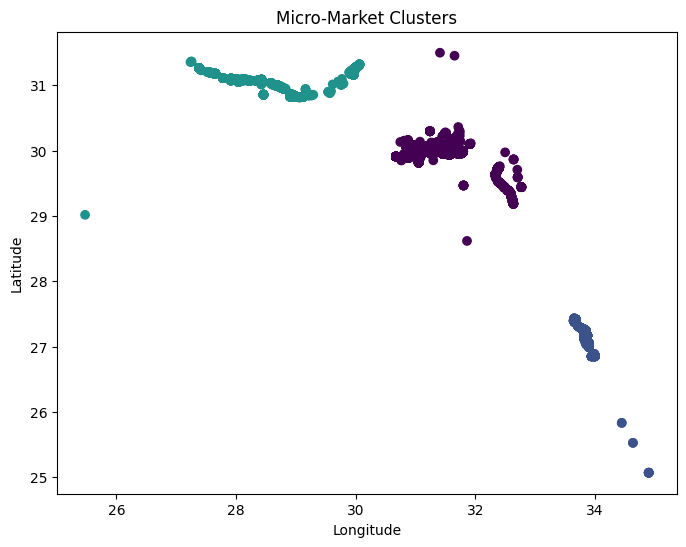

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['lon'], df['lat'], c=df['cluster'], cmap='viridis')
plt.title("Micro-Market Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

🟦 11. Final Insights

* K-Means clustering successfully grouped properties into distinct micro-markets.
* Clusters with lower average price per square foot were identified as undervalued zones.
* Geographic clustering highlights spatial trends in real estate pricing.
* The model provides a data-driven approach to identify potential investment opportunities.

🟦 12. Conclusion

This analysis demonstrates how machine learning techniques can be used to identify undervalued micro-markets in real estate. The results can assist investors and stakeholders in making informed decisions.